# 📚 Section 8. Composite & Special Charts — Heatmap / Pareto / Waterfall / Dual Axis
> 섹션 8. 복합·특수 차트 — Heatmap / Pareto / Waterfall / Dual Axis

---
# 🎯 Learning Objective · 학습 목표
Today I want to learn: · 오늘 배우고 싶은 것:
- [x] Build a Heatmap with `imshow()` and read a fixed-range correlation matrix correctly  
`imshow()`로 Heatmap을 만들고 범위가 고정된 상관관계 매트릭스를 올바르게 읽기
- [x] Build a Pareto Chart and a Waterfall Chart, both of which combine a Bar Chart with something else  
Bar Chart와 다른 요소를 결합한 Pareto Chart와 Waterfall Chart 만들기
- [x] Use `ax.twinx()` to combine two differently-scaled metrics on one Dual Axis chart with a single merged legend  
`ax.twinx()`로 스케일이 다른 두 지표를 하나의 Dual Axis 차트에 결합하고 범례를 하나로 합치기

---
# 🧠 Concept · 개념

## What is it? · 무엇인가?

The 4 charts in this section are all "combination" charts — none of them has a dedicated Matplotlib function. Each one is built by combining basic techniques from earlier sections (`imshow`, `bar`, `plot`, `twinx`) in a specific way. A Heatmap represents a 2D matrix's values as color intensity, turning a table full of numbers into a pattern you can read at a glance.

이 섹션의 4개 차트는 모두 "조합형" 차트입니다 — Matplotlib 전용 함수가 따로 없습니다. 각각은 이전 섹션에서 배운 기본 기법(`imshow`, `bar`, `plot`, `twinx`)을 특정 방식으로 조합해서 만듭니다. Heatmap은 2차원 매트릭스의 값을 색상 진하기로 표현하여, 숫자로 가득한 표를 한눈에 읽을 수 있는 패턴으로 바꿔줍니다.

## Why do we use it? · 왜 사용하는가?

Each of the 4 solves a specific business question that a basic chart can't answer on its own: Heatmap shows a pattern across two categorical axes at once, Pareto shows whether a small number of items drive most of the result, Waterfall shows exactly which factors caused a total to change, and Dual Axis lets two differently-scaled metrics be compared on the same timeline.

4가지 모두 기본 차트 하나로는 답할 수 없는 특정 비즈니스 질문을 해결합니다: Heatmap은 두 범주형 축에 걸친 패턴을 한 번에 보여주고, Pareto는 소수의 항목이 결과 대부분을 차지하는지 보여주고, Waterfall은 정확히 어떤 요인들이 합계를 변화시켰는지 보여주며, Dual Axis는 스케일이 다른 두 지표를 같은 시간축 위에서 비교할 수 있게 해줍니다.

## When is it used in Business Analytics? · 언제 비즈니스 분석에서 사용되는가?

DA/BA situations: traffic patterns by day×hour, correlation matrices between metrics (Heatmap); defect/customer analysis and the 80/20 rule (Pareto); revenue bridge analysis, P&L walkthroughs (Waterfall); revenue vs conversion rate, ad spend vs ROAS (Dual Axis).

DA/BA 실무 상황: 요일×시간대별 트래픽 패턴, 지표 간 상관관계 매트릭스(Heatmap); 불량·고객 분석과 80/20 법칙(Pareto); 매출 브릿지 분석, 손익계산서 워크스루(Waterfall); 매출 대비 전환율, 광고비 대비 ROAS(Dual Axis).

| Situation / 상황 | Chart / 차트 | Why / 이유 |
|---|---|---|
| Pattern across 2 categorical axes / 두 범주형 축에 걸친 패턴 | Heatmap | Color reveals patterns a table can't / 색상이 표로는 안 보이는 패턴을 드러냄 |
| Do a few items drive most of the result? / 소수 항목이 결과 대부분을 차지하는가 | Pareto | Bar + cumulative line shows the 80/20 point / 막대+누적선으로 80/20 지점 표시 |
| What exactly changed a total? / 정확히 무엇이 합계를 바꿨는가 | Waterfall | Floating bars show each factor's contribution / 떠 있는 막대로 각 요인의 기여도 표시 |
| Two metrics, different scales / 스케일이 다른 두 지표 | Dual Axis | Two y-axes share one x-axis / 두 개의 y축이 하나의 x축을 공유 |

---
# 📝 Syntax · 문법

## Basic Syntax · 기본 문법

`ax.imshow(matrix, cmap=...)` draws a 2D array as a color grid. Since it doesn't label the cells for you, a nested loop with `ax.text()` is how you print the actual number inside each cell.

`ax.imshow(matrix, cmap=...)`는 2차원 배열을 색상 격자로 그립니다. 셀 안의 숫자는 자동으로 표시되지 않으므로, 이중 반복문과 `ax.text()`로 각 셀에 실제 숫자를 직접 찍어야 합니다.

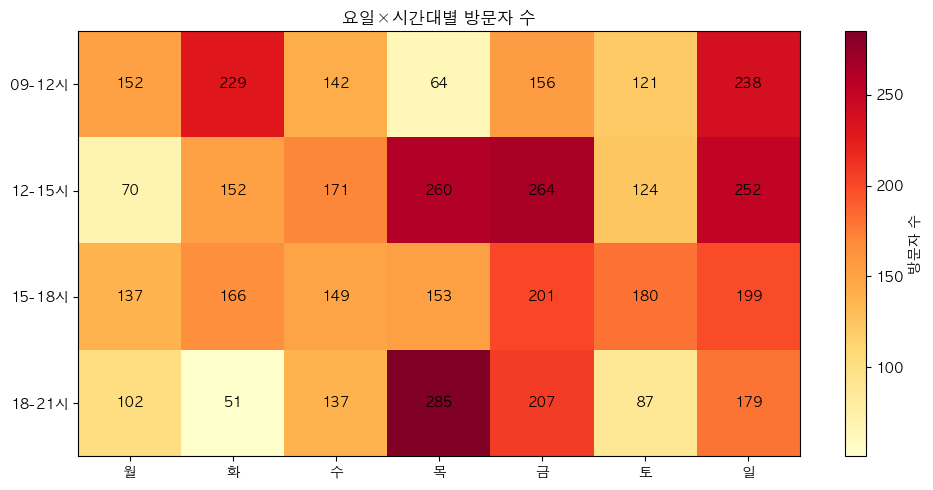

In [1]:
# Basic Syntax: a heatmap of visits by day and hour
# 기본 문법: 요일×시간대별 방문자 수 히트맵

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'   # macOS: 'AppleGothic', Windows: 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

days = ['월', '화', '수', '목', '금', '토', '일']
hours = ['09-12시', '12-15시', '15-18시', '18-21시']

np.random.seed(42)
visits = np.random.randint(50, 300, size=(4, 7))

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(visits, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(days)))
ax.set_xticklabels(days)
ax.set_yticks(range(len(hours)))
ax.set_yticklabels(hours)

for i in range(len(hours)):
    for j in range(len(days)):
        ax.text(j, i, visits[i, j], ha='center', va='center', color='black')

ax.set_title('요일×시간대별 방문자 수')
plt.colorbar(im, ax=ax, label='방문자 수')
plt.tight_layout()
plt.show()

## Common Variations · 주요 변형

Two refinements matter once a Heatmap needs to be compared across multiple charts or read precisely: fixing `vmin`/`vmax` so the color scale means the same thing every time, and switching text color to white on dark cells so numbers stay readable everywhere.

Heatmap을 여러 차트에서 비교하거나 정밀하게 읽어야 할 때는 두 가지 개선이 중요합니다: `vmin`/`vmax`를 고정해 색상 척도가 항상 같은 의미를 갖게 하는 것, 그리고 진한 셀에서는 텍스트 색을 흰색으로 바꿔 어디서든 숫자가 잘 보이게 하는 것입니다.

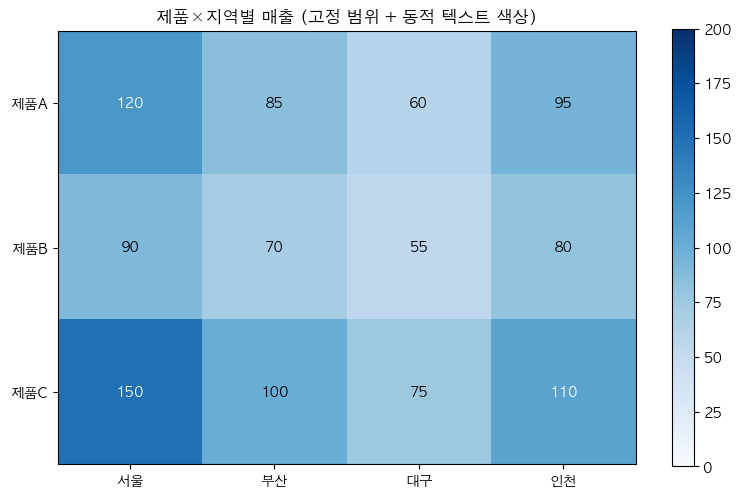

In [2]:
# Common Variations: fixed color range + text color that adapts to the cell
# 주요 변형: 고정된 색상 범위 + 셀에 따라 바뀌는 텍스트 색상

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

products = ['제품A', '제품B', '제품C']
regions = ['서울', '부산', '대구', '인천']
sales_matrix = np.array([[120, 85, 60, 95], [90, 70, 55, 80], [150, 100, 75, 110]])

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(sales_matrix, cmap='Blues', vmin=0, vmax=200)

ax.set_xticks(range(len(regions)))
ax.set_xticklabels(regions)
ax.set_yticks(range(len(products)))
ax.set_yticklabels(products)

for i in range(len(products)):
    for j in range(len(regions)):
        value = sales_matrix[i, j]
        text_color = 'white' if value > 100 else 'black'
        ax.text(j, i, value, ha='center', va='center', color=text_color)

ax.set_title('제품×지역별 매출 (고정 범위 + 동적 텍스트 색상)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

---
# 🧪 Small Examples · 예제

## Example 1: Pareto Chart · 예제 1: 파레토 차트

A Pareto Chart combines a descending Bar Chart with a cumulative-percentage line on a second y-axis via `ax.twinx()`, visualizing the 80/20 rule: do a small number of categories account for most of the total?

Pareto Chart는 내림차순 정렬된 Bar Chart와 `ax.twinx()`로 만든 두 번째 y축의 누적 비율 선을 결합해, "소수의 카테고리가 전체 대부분을 차지하는가"라는 80/20 법칙을 시각화합니다.

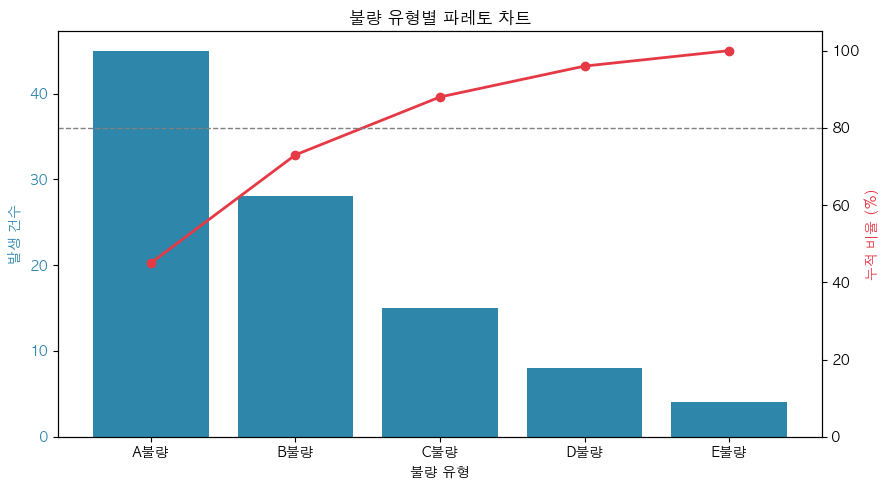

In [3]:
# Example 1: pareto chart of defect types
# 예제 1: 불량 유형별 파레토 차트

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

defects = ['A불량', 'B불량', 'C불량', 'D불량', 'E불량']
counts = [45, 28, 15, 8, 4]

sorted_idx = np.argsort(counts)[::-1]   # descending order index
defects_sorted = [defects[i] for i in sorted_idx]
counts_sorted = [counts[i] for i in sorted_idx]
cumulative_pct = np.cumsum(counts_sorted) / sum(counts_sorted) * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(defects_sorted, counts_sorted, color='#2E86AB')
ax1.set_xlabel('불량 유형')
ax1.set_ylabel('발생 건수', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')

ax2 = ax1.twinx()   # a second y-axis sharing the same x-axis
ax2.plot(defects_sorted, cumulative_pct, color='#E63946', marker='o', linewidth=2)
ax2.set_ylabel('누적 비율 (%)', color='#E63946')
ax2.set_ylim(0, 105)
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1)

ax1.set_title('불량 유형별 파레토 차트')
plt.tight_layout()
plt.show()

## Example 2: Waterfall Chart · 예제 2: 워터폴 차트

A Waterfall Chart shows a starting value moving through several positive/negative factors to a final value, as floating bars. The trick is `bottom=`: a positive factor's bar starts at the running total, a negative factor's bar starts at the running total *plus* its (negative) value, so it visually hangs down from where the previous bar ended.

Waterfall Chart는 시작값이 여러 양수/음수 요인을 거쳐 최종값에 도달하는 과정을 떠 있는 막대로 보여줍니다. 핵심은 `bottom=`입니다: 양수 요인의 막대는 누적값에서 시작하고, 음수 요인의 막대는 누적값에 그 (음수)값을 더한 지점에서 시작해, 이전 막대의 끝에서 아래로 매달린 것처럼 보입니다.

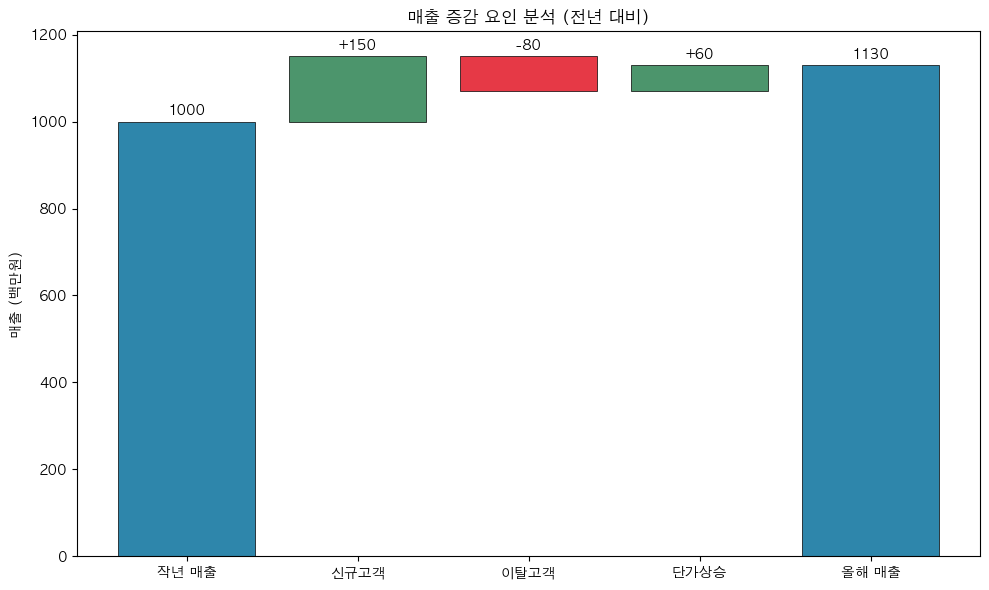

In [4]:
# Example 2: revenue change waterfall
# 예제 2: 매출 증감 요인 워터폴 차트

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

labels = ['작년 매출', '신규고객', '이탈고객', '단가상승', '올해 매출']
deltas = [1000, 150, -80, 60]   # starting value + factor deltas
final = sum(deltas)
values = deltas + [final]        # append the final total

bottoms = [0]
running = values[0]
for v in values[1:-1]:
    bottoms.append(running if v >= 0 else running + v)
    running += v
bottoms.append(0)   # the final total bar always starts at 0

heights = [values[0]] + [abs(v) for v in values[1:-1]] + [values[-1]]
colors = ['#2E86AB'] + ['#4C956C' if v >= 0 else '#E63946' for v in values[1:-1]] + ['#2E86AB']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, heights, bottom=bottoms, color=colors, edgecolor='black', linewidth=0.5)

for i, v in enumerate(values):
    label = f'{v:.0f}' if i in [0, len(values) - 1] else f'{v:+.0f}'
    ax.text(i, bottoms[i] + heights[i] + 15, label, ha='center', fontsize=10, fontweight='bold')

ax.set_title('매출 증감 요인 분석 (전년 대비)')
ax.set_ylabel('매출 (백만원)')
plt.tight_layout()
plt.show()

## Example 3: Dual Axis Chart · 예제 3: 이중 축 차트

`ax1.twinx()` creates a second Axes sharing `ax1`'s x-axis but with its own independent y-axis, letting two differently-scaled metrics (like revenue in millions and a conversion rate in single-digit percent) share one timeline. One easy trap: calling `ax1.legend()` alone only picks up `ax1`'s line — `ax2`'s line needs its handles merged in explicitly with `get_legend_handles_labels()`.

`ax1.twinx()`는 `ax1`의 x축을 공유하지만 독립적인 y축을 가진 두 번째 Axes를 만들어, 스케일이 매우 다른 두 지표(백만원 단위 매출과 한 자릿수 퍼센트의 전환율 등)가 같은 시간축을 공유하게 해줍니다. 흔히 빠지는 함정 하나: `ax1.legend()`만 호출하면 `ax1`의 선만 범례에 잡힙니다 — `ax2`의 선은 `get_legend_handles_labels()`로 핸들을 직접 합쳐줘야 합니다.

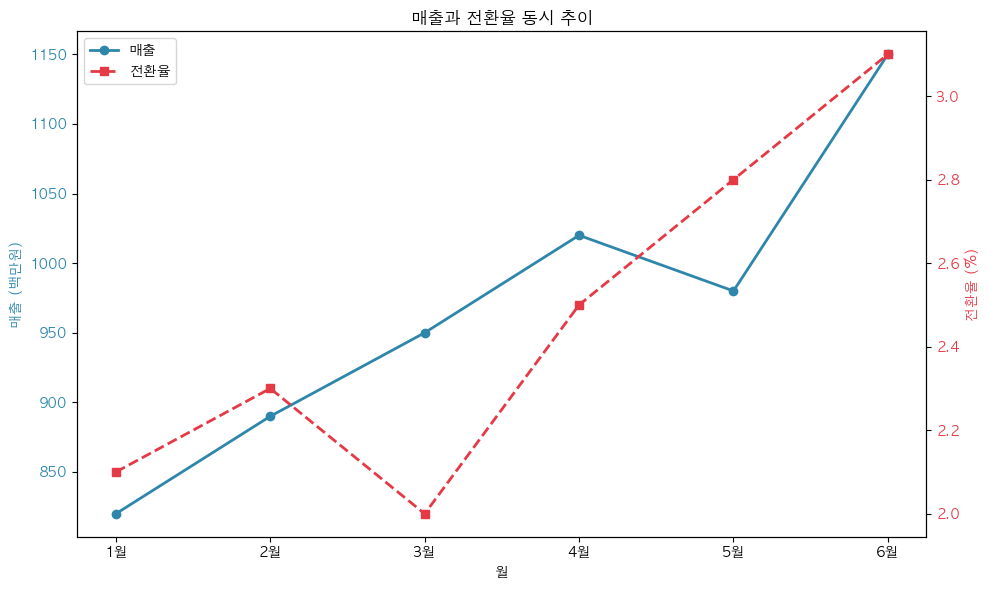

In [5]:
# Example 3: revenue and conversion rate on two y-axes, with one merged legend
# 예제 3: 매출과 전환율을 두 개의 y축으로, 범례는 하나로 합쳐서

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

months = ['1월', '2월', '3월', '4월', '5월', '6월']
revenue = [820, 890, 950, 1020, 980, 1150]
conversion_rate = [2.1, 2.3, 2.0, 2.5, 2.8, 3.1]

fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(months, revenue, color='#2E86AB', marker='o', linewidth=2, label='매출')
ax1.set_xlabel('월')
ax1.set_ylabel('매출 (백만원)', color='#2E86AB')
ax1.tick_params(axis='y', labelcolor='#2E86AB')

ax2 = ax1.twinx()
ax2.plot(months, conversion_rate, color='#E63946', marker='s', linewidth=2, linestyle='--', label='전환율')
ax2.set_ylabel('전환율 (%)', color='#E63946')
ax2.tick_params(axis='y', labelcolor='#E63946')

# merge both axes' legend handles into a single legend box
# 두 축의 범례 핸들을 하나의 범례 박스로 합치기
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

ax1.set_title('매출과 전환율 동시 추이')
plt.tight_layout()
plt.show()

## Example 4: Practice · 예제 4: 연습문제

One short practice per chart type. Each part runs without error either way; the real chart for that part only appears once its own blank is filled in.

차트 유형마다 짧은 연습문제 하나씩입니다. 각 파트는 어떤 상태든 에러 없이 실행되며, 해당 빈칸을 채워야만 그 파트의 실제 차트가 나타납니다.

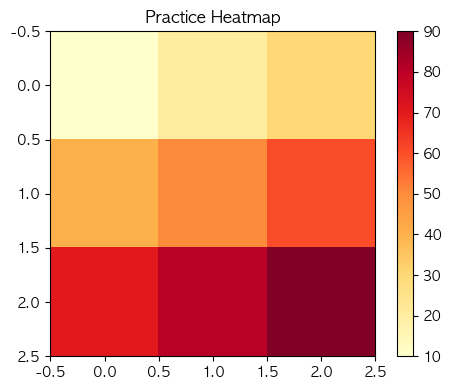

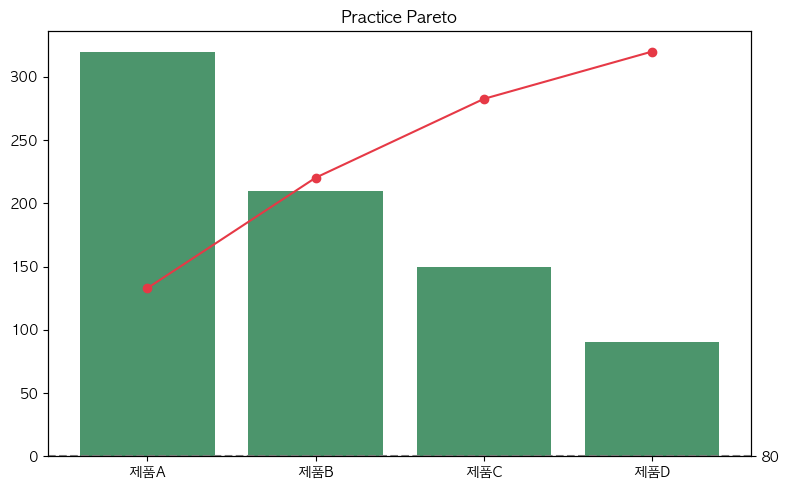

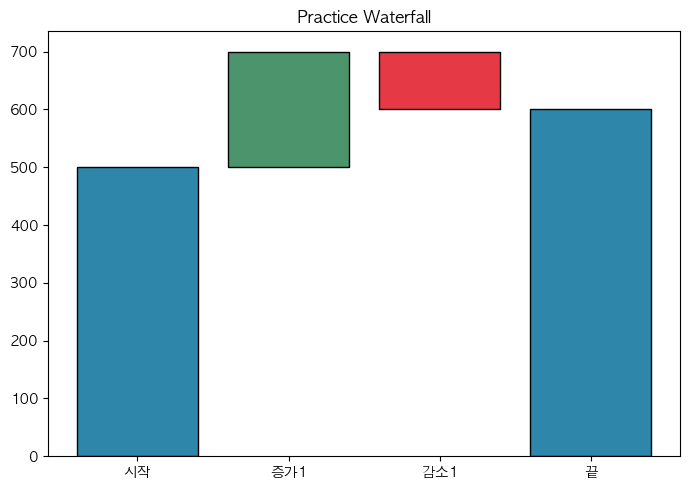

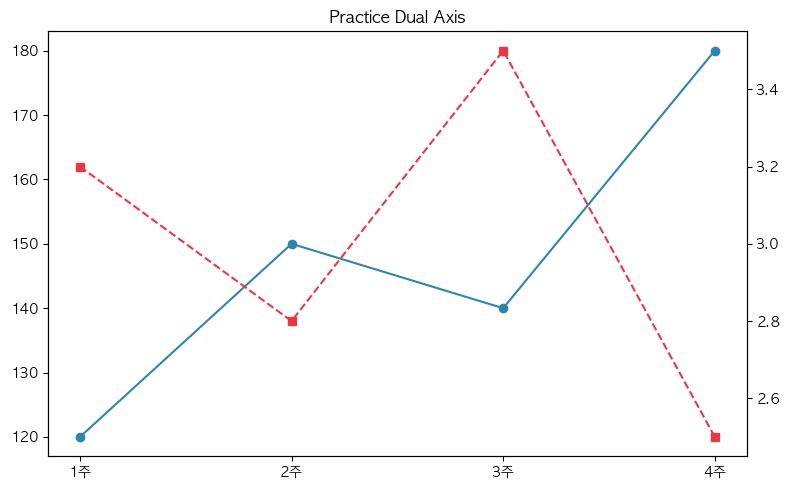

In [8]:
# Practice: fill in the blanks, then re-run this cell
# 연습문제: 빈칸을 채운 후 셀을 다시 실행하세요

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ---- Part A: Heatmap colormap ----
# ---- Part A: Heatmap 컬러맵 ----
matrix = np.array([[10, 20, 30], [40, 50, 60], [70, 80, 90]])
heatmap_cmap = "YlOrRd"   # TODO: a colormap name, e.g. 'YlOrRd'

if heatmap_cmap == "________":
    print("Part A: fill in heatmap_cmap above, then re-run.")
    print("Part A: 위의 heatmap_cmap을 채운 후 다시 실행하세요.")
else:
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(matrix, cmap=heatmap_cmap)
    plt.colorbar(im, ax=ax)
    ax.set_title('Practice Heatmap')
    plt.tight_layout()
    plt.show()

# ---- Part B: Pareto threshold line ----
# ---- Part B: 파레토 기준선 ----
products = ['제품A', '제품B', '제품C', '제품D']
sales = [320, 210, 150, 90]
cumulative_pct = np.cumsum(sales) / sum(sales) * 100

threshold = "80"   # TODO: a number, e.g. 80

if threshold == "________":
    print("Part B: fill in threshold above, then re-run.")
    print("Part B: 위의 threshold를 채운 후 다시 실행하세요.")
else:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.bar(products, sales, color='#4C956C')
    ax2 = ax1.twinx()
    ax2.plot(products, cumulative_pct, color='#E63946', marker='o')
    ax2.axhline(y=threshold, color='gray', linestyle='--')
    ax2.set_ylim(0, 105)
    ax1.set_title('Practice Pareto')
    plt.tight_layout()
    plt.show()

# ---- Part C: Waterfall increase color ----
# ---- Part C: 워터폴 증가 색상 ----
labels = ['시작', '증가1', '감소1', '끝']
deltas = [500, 200, -100]
final = sum(deltas)
values = deltas + [final]

increase_color = "#4C956C"   # TODO: any valid color, e.g. '#4C956C'

if increase_color == "________":
    print("Part C: fill in increase_color above, then re-run.")
    print("Part C: 위의 increase_color를 채운 후 다시 실행하세요.")
else:
    bottoms = [0]
    running = values[0]
    for v in values[1:-1]:
        bottoms.append(running if v >= 0 else running + v)
        running += v
    bottoms.append(0)
    heights = [values[0]] + [abs(v) for v in values[1:-1]] + [values[-1]]
    colors = ['#2E86AB'] + [increase_color if v >= 0 else '#E63946' for v in values[1:-1]] + ['#2E86AB']
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(labels, heights, bottom=bottoms, color=colors, edgecolor='black')
    ax.set_title('Practice Waterfall')
    plt.tight_layout()
    plt.show()

# ---- Part D: Dual Axis second line color ----
# ---- Part D: 이중 축 두 번째 선 색상 ----
weeks = ['1주', '2주', '3주', '4주']
signups = [120, 150, 140, 180]
churn_rate = [3.2, 2.8, 3.5, 2.5]

second_line_color = "#E63946"   # TODO: any valid color, e.g. '#E63946'

if second_line_color == "________":
    print("Part D: fill in second_line_color above, then re-run.")
    print("Part D: 위의 second_line_color를 채운 후 다시 실행하세요.")
else:
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(weeks, signups, color='#2E86AB', marker='o')
    ax2 = ax1.twinx()
    ax2.plot(weeks, churn_rate, color=second_line_color, marker='s', linestyle='--')
    ax1.set_title('Practice Dual Axis')
    plt.tight_layout()
    plt.show()

---
# ⚠️ Common Mistakes · 자주 하는 실수

### Mistake 1: Skipping the colorbar on a Heatmap · 실수 1: 컬러바(colorbar) 생략

Without a colorbar, there's no way to know exactly what value a given color intensity represents.

컬러바가 없으면 특정 색상 진하기가 정확히 어떤 값을 의미하는지 판단할 수 없습니다.

✅ **Fix:** Always call `plt.colorbar(im, ax=ax)` right after `imshow()`.  
✅ **해결:** `imshow()` 직후 항상 `plt.colorbar(im, ax=ax)`를 호출하세요.

### Mistake 2: Fixed text color on a Heatmap · 실수 2: 텍스트 색을 고정(항상 검정)

Black numbers become unreadable once they sit on a dark cell from a strong colormap.

검정 숫자는 컬러맵이 진한 셀 위에 놓이면 읽을 수 없게 됩니다.

✅ **Fix:** Switch text color based on the cell's value, as in Common Variations above.  
✅ **해결:** 위 Common Variations처럼 값 크기에 따라 텍스트 색을 동적으로 바꾸세요.

### Mistake 3: Including the diagonal when finding the "strongest relationship" · 실수 3: 상관관계 매트릭스에서 대각선(자기상관=1)을 포함해 "가장 강한 관계"를 찾음

Every cell on a correlation matrix's diagonal is a metric correlated with itself, always exactly 1.00 — searching for the strongest pair without excluding it always "finds" the diagonal and nothing else.

상관관계 매트릭스의 대각선은 자기 자신과의 상관계수이므로 항상 정확히 1.00입니다 — 대각선을 제외하지 않고 가장 강한 쌍을 찾으면 항상 대각선만 "발견"하게 됩니다.

✅ **Fix:** Loop only over the upper (or lower) triangle, excluding the diagonal, as the Business Example below does with `range(i + 1, ...)`.  
✅ **해결:** 아래 Business Example처럼 `range(i + 1, ...)`로 대각선을 제외한 위쪽(또는 아래쪽) 삼각형만 순회하세요.

### Mistake 4: Forgetting to sort data descending before a Pareto Chart · 실수 4: 데이터를 내림차순 정렬하지 않고 그림

An unsorted Pareto Chart produces a jagged cumulative line instead of the smooth, recognizable 80/20 curve.

정렬하지 않은 파레토 차트는 매끄러운 80/20 곡선 대신 들쭉날쭉한 누적선을 만듭니다.

✅ **Fix:** Always sort by value descending before computing the cumulative percentage.  
✅ **해결:** 누적 비율을 계산하기 전에 항상 값 기준 내림차순으로 정렬하세요.

### Mistake 5: Leaving the cumulative-percent axis unscaled · 실수 5: 누적 비율 축 범위를 0~100으로 고정 안 함

Without `ax2.set_ylim(0, 105)`, comparing several Pareto charts side by side becomes misleading since each chart's y-range auto-adjusts differently.

`ax2.set_ylim(0, 105)`가 없으면 여러 파레토 차트를 나란히 비교할 때 차트마다 y축 범위가 제각각 자동 조정되어 오해를 일으킵니다.

✅ **Fix:** Fix the cumulative axis to `(0, 105)` every time so charts stay visually comparable.  
✅ **해결:** 누적 축을 항상 `(0, 105)`로 고정해 차트끼리 시각적으로 비교 가능하게 하세요.

### Mistake 6: Skipping the 80% reference line · 실수 6: 80% 기준선 생략

Without a visual marker at 80%, "where do the vital few end and the trivial many begin" becomes a judgment call instead of something the chart answers directly.

80% 지점에 시각적 표시가 없으면, "핵심 소수는 어디까지고 나머지 다수는 어디부터인가"가 차트가 직접 답해주는 것이 아니라 보는 사람의 판단에 맡겨집니다.

✅ **Fix:** Always draw `ax2.axhline(y=80, color='gray', linestyle='--')` so the 80/20 cutoff is explicit.  
✅ **해결:** 항상 `ax2.axhline(y=80, color='gray', linestyle='--')`로 80/20 기준선을 명시적으로 표시하세요.

### Mistake 7: Wrong bottom= for a negative Waterfall bar · 실수 7: 음수 항목의 bottom 계산 실수

Using the running total *before* the drop (instead of the total *after* it) as `bottom` makes a negative bar float in the wrong place or pierce through the previous bar.

떨어지기 *전*의 누적값을 (떨어진 *후*의 값이 아니라) `bottom`으로 쓰면 음수 막대가 공중에 뜨거나 이전 막대를 뚫고 지나가게 그려집니다.

✅ **Fix:** For a negative delta, `bottom` must equal the running total *after* adding that (negative) delta — see the `running + v` logic in Example 2.  
✅ **해결:** 음수 값의 경우 `bottom`은 그 (음수) 값을 더한 *이후*의 누적값이어야 합니다 — Example 2의 `running + v` 로직을 참고하세요.

### Mistake 8: Start/end bars using the running bottom · 실수 8: 시작값·종료값 막대도 bottom=running으로 그림

The first and last bars represent absolute totals, not deltas — if they inherit a nonzero `bottom` from the loop logic, the whole chart looks visually broken.

첫 번째와 마지막 막대는 증감이 아니라 절대적인 합계값을 나타냅니다 — 반복문 로직에서 0이 아닌 `bottom`을 물려받으면 차트 전체가 시각적으로 어긋나 보입니다.

✅ **Fix:** Always force the start and end bars' `bottom` to exactly `0`.  
✅ **해결:** 시작·종료 막대의 `bottom`은 항상 정확히 `0`으로 고정하세요.

### Mistake 9: Mismatched colors between line and axis label · 실수 9: 두 축의 색상을 통일하지 않음

If a line is blue but its y-axis label and ticks are left in the default black, readers can't immediately tell which line belongs to which axis.

선은 파란색인데 y축 라벨과 눈금은 기본 검정색으로 남겨두면, 독자가 어떤 선이 어떤 축에 해당하는지 즉시 알 수 없습니다.

✅ **Fix:** Match the line color, `ylabel` color, and `tick_params(labelcolor=...)` for each axis.  
✅ **해결:** 선 색상, `ylabel` 색상, `tick_params(labelcolor=...)`를 각 축마다 일치시키세요.

### Mistake 10: Calling only ax1.legend() on a Dual Axis chart · 실수 10: ax1.legend()만 호출

`ax1.legend()` only knows about `ax1`'s own lines — `ax2`'s line silently gets left out of the legend box entirely, even though it's clearly visible on the chart.

`ax1.legend()`는 `ax1`에 그려진 선만 알고 있습니다 — `ax2`의 선은 차트에는 분명히 보이는데도 범례 박스에서는 조용히 빠지게 됩니다.

✅ **Fix:** Collect both axes' handles with `get_legend_handles_labels()` and pass the merged lists to a single `legend()` call, as Example 3 above does.  
✅ **해결:** 위 Example 3처럼 `get_legend_handles_labels()`로 양쪽 축의 핸들을 모두 모아 하나의 `legend()` 호출에 합쳐서 전달하세요.

### Mistake 11: Forcing two weakly-related metrics onto Dual Axis · 실수 11: 관계가 약한 두 지표를 억지로 겹쳐서 표시

Freely adjusting each axis's scale can make two barely-related metrics look like they move together, creating a misleading visual impression — this is a well-known way Dual Axis charts get misused.

각 축의 스케일을 자유롭게 조정하면 실제로는 관계가 약한 두 지표도 함께 움직이는 것처럼 보이게 만들 수 있어, 오해를 유발하는 시각적 인상을 줍니다 — Dual Axis 차트가 오용되는 대표적인 방식입니다.

✅ **Fix:** Check the actual correlation coefficient before pairing two metrics on Dual Axis, and disclose it if the relationship is weak.  
✅ **해결:** 두 지표를 Dual Axis로 짝짓기 전에 실제 상관계수를 확인하고, 관계가 약하다면 그 사실을 함께 밝히세요.

---
# 💡 Tips · 팁
Useful tips or shortcuts · 유용한 팁과 지름길

- Always pair `imshow()` with `plt.colorbar()`, and fix `vmin`/`vmax` whenever you'll compare multiple heatmaps.  
`imshow()`에는 항상 `plt.colorbar()`를 함께 쓰고, 여러 히트맵을 비교할 계획이라면 `vmin`/`vmax`를 고정하세요.
- For a Pareto Chart, sort descending first, then fix the cumulative axis to `(0, 105)` — both steps are what make the "80/20 shape" actually visible.  
Pareto Chart는 먼저 내림차순 정렬하고, 누적 축을 `(0, 105)`로 고정하세요 — 두 단계 모두 "80/20 모양"을 실제로 보이게 만드는 핵심입니다.
- For a Waterfall Chart, keep a running-total variable and update `bottom` from it on every iteration, rather than recomputing from scratch each time.  
Waterfall Chart는 누적 합계 변수를 유지하고, 매번 새로 계산하지 말고 매 반복마다 그 변수로 `bottom`을 갱신하세요.
- Before building a Dual Axis chart, check the correlation coefficient between the two metrics — Dual Axis should reveal a real relationship, not manufacture the appearance of one.  
Dual Axis 차트를 만들기 전에 두 지표 간 상관계수를 확인하세요 — Dual Axis는 실제 관계를 드러내야지, 관계가 있는 것처럼 꾸며내면 안 됩니다.

---
# 🔗 Related Concepts · 관련 개념

```
   Section 7: Ratio Charts   (Pie / Donut / Treemap)
                ↓
   Section 8: Composite & Special Charts   ←  YOU ARE HERE / 지금 여기
   (Heatmap / Pareto / Waterfall / Dual Axis - combining earlier techniques)
                ↓
   Section 9: Subplots & Dashboards
   (combining entire CHARTS, the same instinct one level up)
```

*How is today's topic connected to other concepts?* · *오늘 배운 내용이 다른 개념과 어떻게 연결되는가?*

Every technique here is a remix of something already learned: Heatmap reuses the grid-and-color idea from Section 7's Treemap color encoding, Pareto and Waterfall both extend Section 4's `ax.bar()` (cumulative line and floating `bottom=`, respectively), and Dual Axis's `ax.twinx()` was already previewed inside this section's own Pareto example. Section 9 takes this same "combine what you know" instinct one level up — combining entire charts, rather than combining techniques within one chart.

이 섹션의 모든 기법은 이미 배운 것을 새롭게 조합한 것입니다: Heatmap은 섹션 7 Treemap의 색상 인코딩 아이디어를 격자에 재사용하고, Pareto와 Waterfall은 각각 섹션 4의 `ax.bar()`를 확장(누적선, 떠 있는 `bottom=`)하며, Dual Axis의 `ax.twinx()`는 이미 이 섹션의 Pareto 예제 안에서 미리 등장했습니다. 섹션 9는 이 "아는 것을 조합한다"는 감각을 한 단계 위로 끌어올려 — 한 차트 안의 기법이 아니라 차트 전체를 조합합니다.

---
# 💼 Business Example · 비즈니스 예제
*How would a Business Analyst use this?* · *비즈니스 분석가는 이것을 어떻게 활용할까?*

**Scenario / 시나리오:**
Your manager suspects your marketing metrics might be redundant — maybe ad spend and revenue are basically measuring the same thing twice. You're asked to check every pairwise relationship among 4 key metrics at once.

매니저가 마케팅 지표들이 중복되는 것 아닌지 의심합니다 — 광고비와 매출이 사실상 같은 것을 두 번 측정하는 건 아닌지 말이죠. 4개 핵심 지표 사이의 모든 쌍별 관계를 한 번에 확인해달라는 요청을 받았습니다.

**To-Do / 할 일:**
- [x] Compute the full correlation matrix for all 4 metrics with `np.corrcoef()`  
`np.corrcoef()`로 4개 지표의 전체 상관관계 매트릭스 계산하기
- [x] Visualize it as a Heatmap with a fixed `-1` to `1` color range and readable text on every cell  
`-1`~`1`로 범위를 고정한 Heatmap으로 시각화하고 모든 셀에서 텍스트가 잘 보이게 하기
- [x] Programmatically identify and report the single strongest relationship  
가장 강한 관계를 프로그래밍적으로 찾아 보고하기

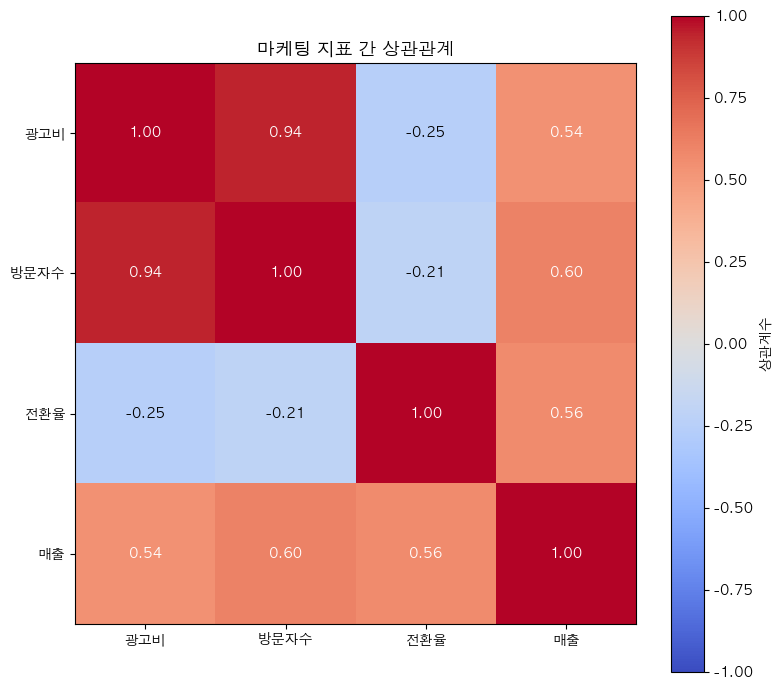

Strongest relationship / 가장 강한 상관관계: 광고비 - 방문자수 (0.94)


In [7]:
# Business Example: correlation heatmap across 4 marketing metrics
# 비즈니스 예제: 4개 마케팅 지표 간 상관관계 히트맵

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
n = 100
ad_spend = np.random.uniform(100, 1000, n)
visitors = ad_spend * 5 + np.random.normal(0, 500, n)
conversion_rate = np.random.uniform(1, 5, n) - ad_spend * 0.001
revenue = visitors * conversion_rate * 50 + np.random.normal(0, 1000, n)

data_matrix = np.array([ad_spend, visitors, conversion_rate, revenue])
labels = ['광고비', '방문자수', '전환율', '매출']
corr_matrix = np.corrcoef(data_matrix)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        text_color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color=text_color)

ax.set_title('마케팅 지표 간 상관관계', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='상관계수')
plt.tight_layout()
fig.savefig('marketing_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# find the strongest relationship, excluding the diagonal (self-correlation = 1.0)
# 가장 강한 관계 찾기 (대각선의 자기상관=1.0 제외)
pairs = []
for i in range(len(labels)):
    for j in range(i + 1, len(labels)):
        pairs.append((labels[i], labels[j], corr_matrix[i, j]))
strongest = max(pairs, key=lambda x: abs(x[2]))
print(f"Strongest relationship / 가장 강한 상관관계: {strongest[0]} - {strongest[1]} ({strongest[2]:.2f})")

---
# 📝 Summary · 요약
*Write today's concept in 3~5 sentences.* · *오늘 배운 개념을 3~5문장으로 정리하세요.*

All 4 charts in this section combine basic techniques rather than using a dedicated Matplotlib function: Heatmap uses `imshow()` plus a manual text loop, Pareto and Waterfall extend `ax.bar()` with a cumulative line and floating `bottom=` values, and Dual Axis uses `ax.twinx()` to give two metrics independent y-axes on a shared x-axis. A Heatmap needs a colorbar and often a fixed `vmin`/`vmax` to stay comparable and readable; a Pareto Chart needs its data sorted descending and its cumulative axis fixed to `(0, 105)`; a Waterfall Chart needs careful `bottom=` bookkeeping so negative bars hang correctly and the start/end bars always begin at 0; and a Dual Axis chart is only honest when the two metrics it pairs actually have a meaningful relationship, which the correlation coefficient can confirm. Every technique here directly reuses something from an earlier section, applied in a new combination.

이 섹션의 4개 차트는 모두 Matplotlib 전용 함수 대신 기본 기법을 조합해서 만듭니다: Heatmap은 `imshow()`와 수동 텍스트 반복문을, Pareto와 Waterfall은 `ax.bar()`를 누적선과 떠 있는 `bottom=` 값으로 확장하며, Dual Axis는 `ax.twinx()`로 두 지표에 독립적인 y축을 부여합니다. Heatmap은 컬러바가 필요하고 비교·가독성을 위해 `vmin`/`vmax`를 고정하는 경우가 많으며, Pareto Chart는 데이터를 내림차순 정렬하고 누적 축을 `(0, 105)`로 고정해야 하고, Waterfall Chart는 음수 막대가 올바르게 매달리고 시작·종료 막대가 항상 0에서 시작하도록 `bottom=` 계산을 신중히 관리해야 합니다. Dual Axis 차트는 짝지은 두 지표가 실제로 의미 있는 관계를 가질 때만 정직하며, 이는 상관계수로 확인할 수 있습니다. 이 섹션의 모든 기법은 이전 섹션에서 배운 것을 새로운 조합으로 재사용한 것입니다.

---
# 📌 One Sentence Summary · 한 줄 요약
Today's topic in ONE sentence. · 오늘의 주제를 한 문장으로.

> Heatmap, Pareto, Waterfall, and Dual Axis all solve one specific business question by recombining techniques you already know — `imshow()`, `ax.bar()`, and `ax.twinx()` — rather than by learning anything entirely new.

> Heatmap, Pareto, Waterfall, Dual Axis는 모두 완전히 새로운 것을 배우는 게 아니라 이미 알고 있는 기법 — `imshow()`, `ax.bar()`, `ax.twinx()` — 을 재조합해서 각각 특정 비즈니스 질문 하나를 해결한다.

---
# ❓ Review Questions · 복습 문제

**Q1.** Why does `imshow()` need a manual `for` loop with `ax.text()` to show numbers, unlike `ax.bar()` or `ax.pie()`?
`ax.bar()`나 `ax.pie()`와 달리, `imshow()`는 왜 숫자를 표시하려면 수동으로 `for` 반복문과 `ax.text()`가 필요한가?

**Q2.** What two steps turn a plain Bar Chart into a proper Pareto Chart?
평범한 Bar Chart를 제대로 된 Pareto Chart로 바꾸는 두 단계는 무엇인가?

**Q3.** In a Waterfall Chart, why does a negative delta's bar need `bottom = running_total + delta` instead of just `bottom = running_total`?
Waterfall Chart에서, 음수 값의 막대는 왜 그냥 `bottom = 누적값`이 아니라 `bottom = 누적값 + delta`가 필요한가?

**Q4.** What does `ax1.twinx()` create, and why must the line color, ylabel color, and tick color all match on each axis?
`ax1.twinx()`는 무엇을 생성하며, 선 색상·ylabel 색상·눈금 색상이 각 축마다 왜 모두 일치해야 하는가?

**Q5.** A colleague wants to put stock price and daily rainfall on the same Dual Axis chart because "it looks interesting." What should you check before agreeing, and why?
동료가 "보기에 흥미로울 것 같다"며 주가와 일일 강수량을 같은 Dual Axis 차트에 넣고 싶어 한다. 동의하기 전에 무엇을 확인해야 하며, 그 이유는 무엇인가?

---
*📅 Try answering these again in a few days.* · *📅 며칠 후에 다시 답해보세요.*